# Encoding Numerical features

In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score  # used for checking accuracy of the prection model
from sklearn.model_selection import cross_val_score  

from sklearn.preprocessing import KBinsDiscretizer  # importing descretization
from sklearn.compose import ColumnTransformer  # column transformer is just like as pipeline that is uses for applying transformation over multiple column at the single time

In [3]:
data = pd.read_csv('../../datasets/titanic2.csv',usecols=['Age','Fare','Survived'])

In [4]:
data.head(3)

,Survived,Age,Fare
0,0,34.5,7.8292
1,1,47.0,7.0000
2,0,62.0,9.6875


In [5]:
data.isnull().sum()

Survived     0
Age         86
Fare         1
dtype: int64

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  418 non-null    int64  
 1   Age       332 non-null    float64
 2   Fare      417 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 9.9 KB


In [7]:
data.shape

(418, 3)

In [8]:
# dropping the null values 
data.dropna(inplace=True)

In [9]:
data.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [10]:
data.shape

(331, 3)

In [11]:
data.head(1)

,Survived,Age,Fare
0,0,34.5,7.8292


In [12]:
x = data.iloc[:,1:]

In [13]:
x

,Age,Fare
0,34.5,7.8292
1,47.0,7.0000
2,62.0,9.6875
3,27.0,8.6625
4,22.0,12.2875
...,...,...
409,3.0,13.7750
411,37.0,90.0000
412,28.0,7.7750
414,39.0,108.9000


In [14]:
y = data.iloc[:,0:1]

In [15]:
y.head(3)

,Survived
0,0
1,1
2,0


In [16]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

In [17]:
# DecisionTreeClassifier object
clf = DecisionTreeClassifier()

In [18]:
# learning parameter for prediction 
clf.fit(x_train,y_train)
y_pred = clf.predict(x_test)

In [19]:
# accuracy score
accuracy_score(y_pred,y_test)

0.59

In [20]:
# cross val is used for cheking prediction multiple times
np.mean(cross_val_score(clf,x,y,cv=10,scoring='accuracy')) # It predict the actual prediction

np.float64(0.5801247771836009)

In [21]:
# creating kbins_objects
kbin_age = KBinsDiscretizer(n_bins=10,encode='ordinal',strategy='quantile')
kbin_fare = KBinsDiscretizer(n_bins=10,encode='ordinal',strategy='quantile')

In [22]:
trf = ColumnTransformer([
    ('first',kbin_age,[0]), # (name,kbindiscretiser object,index)
    ('second',kbin_fare,[1])
])

In [23]:
# converting the x_train and x_test into quantile form
x_train_trf = trf.fit_transform(x_train)
x_test_trf = trf.fit_transform(x_test)

C:\Users\dspri\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
C:\Users\dspri\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
C:\Users\dspri\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be ch

In [26]:
trf.named_transformers_['first']

,"n_bins n_bins: int or array-like of shape (n_features,), default=5The number of bins to produce. Raises ValueError if ``n_bins < 2``.",10
,"encode encode: {'onehot', 'onehot-dense', 'ordinal'}, default='onehot'Method used to encode the transformed result.- 'onehot': Encode the transformed result with one-hot encoding and return a sparse matrix. Ignored features are always stacked to the right.- 'onehot-dense': Encode the transformed result with one-hot encoding and return a dense array. Ignored features are always stacked to the right.- 'ordinal': Return the bin identifier encoded as an integer value.",'ordinal'
,"strategy strategy: {'uniform', 'quantile', 'kmeans'}, default='quantile'Strategy used to define the widths of the bins.- 'uniform': All bins in each feature have identical widths.- 'quantile': All bins in each feature have the same number of points.- 'kmeans': Values in each bin have the same nearest center of a 1D k-means cluster.For an example of the different strategies see::ref:`sphx_glr_auto_examples_preprocessing_plot_discretization_strategies.py`.",'quantile'
,"quantile_method quantile_method: {""inverted_cdf"", ""averaged_inverted_cdf"",""closest_observation"", ""interpolated_inverted_cdf"", ""hazen"",""weibull"", ""linear"", ""median_unbiased"", ""normal_unbiased""},default=""linear""Method to pass on to np.percentile calculation when usingstrategy=""quantile"". Only `averaged_inverted_cdf` and `inverted_cdf`support the use of `sample_weight != None` when subsampling is notactive... versionadded:: 1.7",'warn'
,"dtype dtype: {np.float32, np.float64}, default=NoneThe desired data-type for the output. If None, output dtype isconsistent with input dtype. Only np.float32 and np.float64 aresupported... versionadded:: 0.24",None
,"subsample subsample: int or None, default=200_000Maximum number of samples, used to fit the model, for computationalefficiency.`subsample=None` means that all the training samples are used whencomputing the quantiles that determine the binning thresholds.Since quantile computation relies on sorting each column of `X` andthat sorting has an `n log(n)` time complexity,it is recommended to use subsampling on datasets with avery large number of samples... versionchanged:: 1.3 The default value of `subsample` changed from `None` to `200_000` when `strategy=""quantile""`... versionchanged:: 1.5 The default value of `subsample` changed from `None` to `200_000` when `strategy=""uniform""` or `strategy=""kmeans""`.",200000
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for subsampling.Pass an int for reproducible results across multiple function calls.See the `subsample` parameter for more details.See :term:`Glossary `... versionadded:: 1.1",None


In [27]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.17, 12.9 , 18.4 , 21.7 , 23.6 , 26.  , 28.  , 32.  , 40.  ,
              46.2 , 76.  ])                                                ],
      dtype=object)

In [28]:
x_train_trf.shape

(231, 2)

In [32]:
# creating a column output
output = pd.DataFrame({
    'age':x_train['Age'],
    'age_trf':x_train_trf[:,0],
    'fare' : x_train['Fare'],
    'fare_trf':x_train_trf[:,1]
})

In [33]:
# age and fare level
output['age_label'] = pd.cut(x=x_train['Age'],bins=trf.named_transformers_['first'].bin_edges_[0].tolist())
output['fare_label'] = pd.cut(x=x_train['Fare'],bins=trf.named_transformers_['second'].bin_edges_[0].tolist())

In [35]:
output.head(20)

,age,age_trf,fare,fare_trf,age_label,fare_label
24,48.0,8.0,262.3750,9.0,"(46.2, 76.0]","(78.885, 263.0]"
359,30.0,5.0,15.5500,4.0,"(28.0, 32.0]","(12.01, 15.55]"
371,31.0,5.0,134.5000,9.0,"(28.0, 32.0]","(78.885, 263.0]"
67,47.0,8.0,42.4000,7.0,"(46.2, 76.0]","(31.421, 53.568]"
218,50.0,9.0,211.5000,9.0,"(46.2, 76.0]","(78.885, 263.0]"
11,46.0,8.0,26.0000,6.0,"(40.0, 46.2]","(24.89, 31.421]"
346,26.0,4.0,13.0000,4.0,"(23.6, 26.0]","(12.01, 15.55]"
285,36.0,6.0,7.2500,0.0,"(32.0, 40.0]","(6.496, 7.733]"
99,33.0,6.0,8.0500,2.0,"(32.0, 40.0]","(7.863, 8.662]"
193,61.0,9.0,12.3500,3.0,"(46.2, 76.0]","(12.01, 15.55]"


In [37]:
x_train_trf

array([[8., 9.],
       [5., 4.],
       [5., 9.],
       [8., 7.],
       [9., 9.],
       [8., 6.],
       [4., 4.],
       [6., 0.],
       [6., 2.],
       [9., 3.],
       [8., 6.],
       [5., 1.],
       [6., 2.],
       [6., 1.],
       [1., 8.],
       [3., 3.],
       [5., 9.],
       [7., 8.],
       [5., 4.],
       [5., 5.],
       [8., 0.],
       [8., 9.],
       [8., 3.],
       [1., 7.],
       [9., 8.],
       [6., 5.],
       [9., 9.],
       [5., 2.],
       [9., 9.],
       [1., 4.],
       [5., 6.],
       [0., 4.],
       [1., 8.],
       [0., 4.],
       [9., 4.],
       [8., 7.],
       [2., 7.],
       [3., 1.],
       [8., 8.],
       [7., 8.],
       [3., 1.],
       [9., 9.],
       [4., 5.],
       [9., 6.],
       [0., 4.],
       [9., 7.],
       [2., 5.],
       [4., 1.],
       [5., 6.],
       [0., 4.],
       [1., 1.],
       [6., 2.],
       [4., 4.],
       [4., 2.],
       [1., 2.],
       [7., 9.],
       [6., 1.],
       [0., 7.],
       [1., 2.

In [38]:
# prediction after applying the transformation
clf = DecisionTreeClassifier()
clf.fit(x_train_trf,y_train)
y_pred2 = clf.predict(x_test_trf)

In [40]:
# calculating accuracy after applying transformation
accuracy_score(y_test,y_pred2)

0.57

In [41]:
# accuracy score before applying transformation
accuracy_score(y_test,y_pred)

0.59

In [44]:
# cross checking accuracy
x_trf = trf.fit_transform(x)
np.mean(cross_val_score(DecisionTreeClassifier(),x,y,cv=10,scoring='accuracy'))

C:\Users\dspri\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
C:\Users\dspri\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


np.float64(0.556060606060606)

In [52]:
# WAF to draw the graph before and after transformation
def descretizer(bins,strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    # traformer
    trf = ColumnTransformer([
        ('first',kbin_age,[0]),
        ('second',kbin_fare,[1])
        ])
    # transforming the x data column
    x_trf = trf.fit_transform(x)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),x_trf,y,cv=10,scoring='accuracy')))

    # drawing the curve before applying transformation
    plt.figure(figsize=(14,5))
    plt.subplot(1,2,1)
    plt.hist(x['Age'])
    plt.title('Age Before tranformation')

    # drawing curve after applying the transformation
    plt.subplot(1,2,2)
    plt.hist(x_trf[:,0],color='red')
    plt.title('Age After Transformation')
    plt.show()

    # drawing the graph before and after applying transformation in the fare column
    plt.figure(figsize=(14,5))
    plt.subplot(1,2,1)
    plt.hist(x['Fare'])
    plt.title('Fare Before transformation' )

    # Fare graph after applying transformation
    plt.subplot(1,2,2)
    plt.hist(x_trf[:,1],color='green')
    plt.title('Fare After transforamtion')
    plt.show()

C:\Users\dspri\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
C:\Users\dspri\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


0.5590909090909092


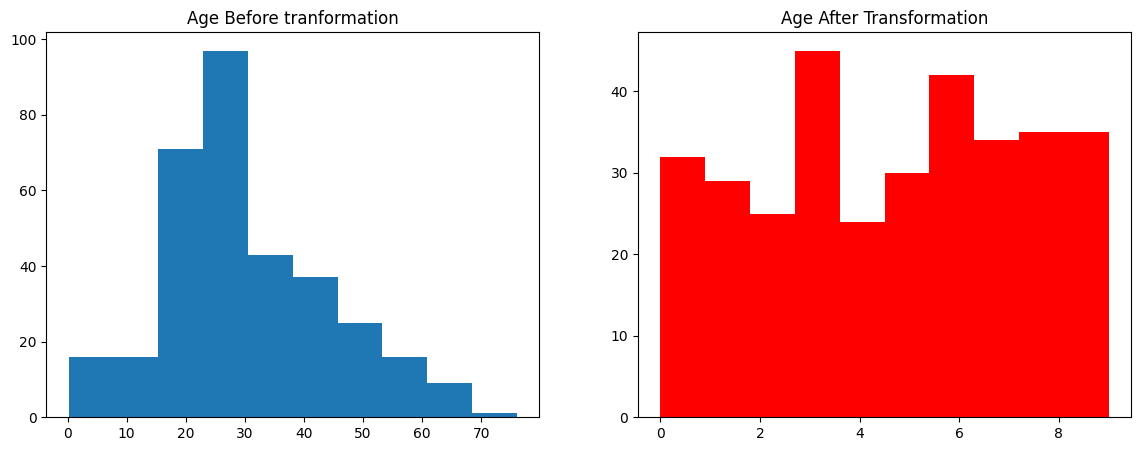

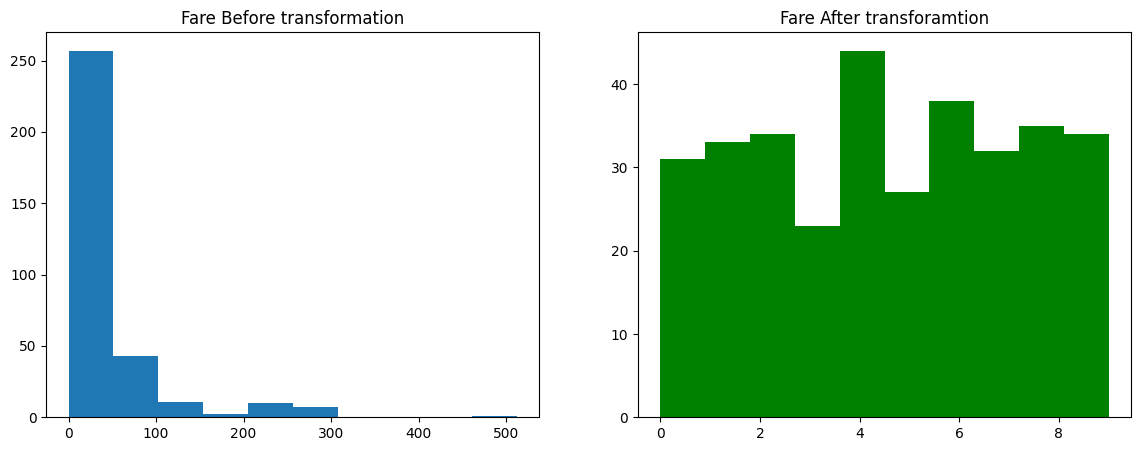

In [53]:
descretizer(10,'quantile')

C:\Users\dspri\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\dspri\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


0.6014260249554367


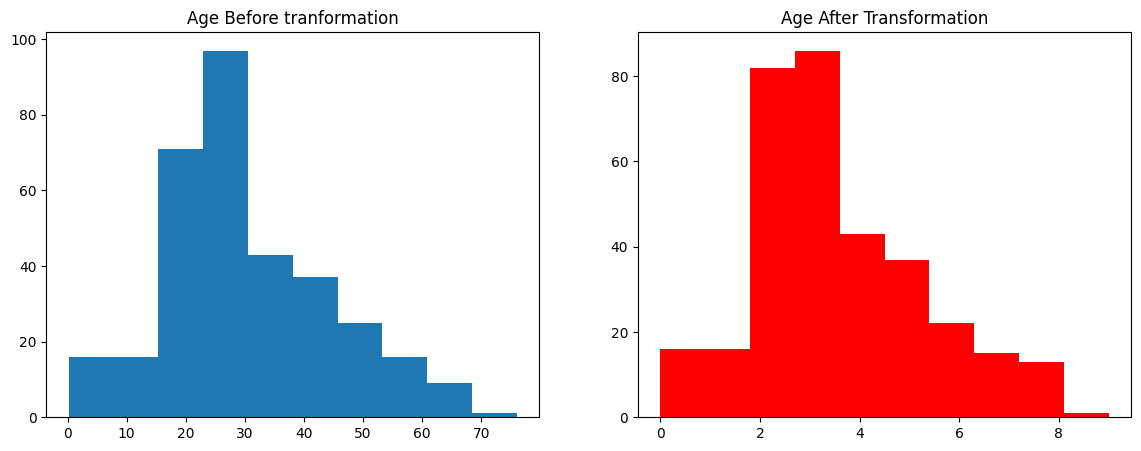

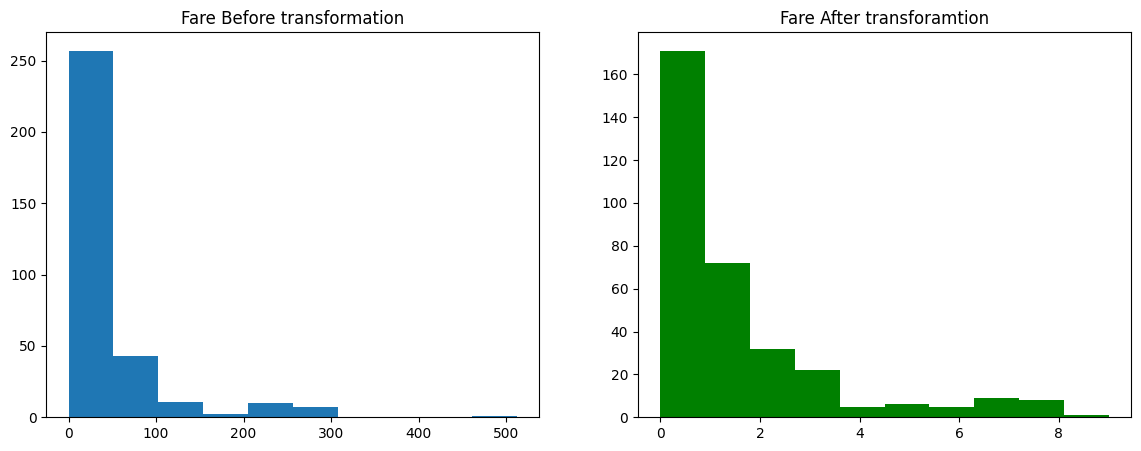

In [55]:
descretizer(10,'kmeans')